In [1]:
!python --version

Python 3.13.2


## **Yield Curve Modeling**

- **a.** Pick government securities from a country. The country selected should be one of the countries from your group so that you can fit a Nelson-Siegel model.  
- **b.** Be sure to pick maturities ranging from short-term to long-term (e.g., 6-month maturity to 20 or 30-year maturities).  
- **c.** Fit a Nelson-Siegel model.  
- **d.** Fit a Cubic-Spline model.  
- **e.** Compare the models in terms of:
  1. Fit  
  2. Interpretation  
- **f.** Be sure to specify at the levels of model parameters (e.g., Alpha1).  
- **g.** In *Module 2 Lesson 4* (“Smoothing Data”), we said smoothing data can be unethical.  
  If Nelson-Siegel is smoothing the yield curve, is this considered unethical? Why or why not?  


In [3]:
!which python

'which' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
# !pip install fredapi

In [3]:
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [4]:
FRED_KEY='f3d5c19309a39daff9cf1584e1128736'

In [5]:
fred = Fred(api_key=FRED_KEY)

In [7]:
# List of Treasury yield series IDs
series_ids = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', \
              'DGS7', 'DGS10', 'DGS20', 'DGS30']

# Function to get data for a single series
def get_yield_data(series_id):
    data = fred.get_series(series_id, observation_start="1975-01-01", observation_end="2024-05-03")
    return data

# Get data for all series
yields_dict = {series_id: get_yield_data(series_id) for series_id in series_ids}

# Combine into a single DataFrame
yields = pd.DataFrame(yields_dict)

# Rename columns for clarity
yields.columns = ['1 Month', '3 Month', '6 Month', '1 Year', '2 Year', '3 Year', '5 Year', \
                  '7 Year', '10 Year', '20 Year', '30 Year']

In [10]:
display(yields)

,1 Month,3 Month,6 Month,1 Year,2 Year,3 Year,5 Year,7 Year,10 Year,20 Year,30 Year
1975-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-01-02,NaN,NaN,NaN,7.27,NaN,7.34,7.34,7.34,7.42,7.94,NaN
1975-01-03,NaN,NaN,NaN,7.19,NaN,7.33,7.36,7.36,7.43,7.92,NaN
1975-01-06,NaN,NaN,NaN,7.10,NaN,7.29,7.34,7.33,7.39,7.89,NaN
1975-01-07,NaN,NaN,NaN,7.00,NaN,7.26,7.35,7.34,7.38,7.89,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2024-04-29,5.48,5.45,5.43,5.20,4.97,4.80,4.65,4.64,4.63,4.86,4.75
2024-04-30,5.48,5.46,5.44,5.25,5.04,4.87,4.72,4.71,4.69,4.90,4.79
2024-05-01,5.47,5.46,5.43,5.21,4.96,4.79,4.64,4.64,4.63,4.85,4.74
2024-05-02,5.51,5.46,5.42,5.16,4.87,4.71,4.57,4.57,4.58,4.82,4.72


In [11]:
yields.index = pd.to_datetime(yields.index)

In [15]:
# yields

In [13]:
yields = yields.dropna()
y_std = yields.std()
y_std

1 Month    1.705851
3 Month    1.733347
6 Month    1.746829
1 Year     1.684091
2 Year     1.545413
3 Year     1.446639
5 Year     1.309345
7 Year     1.226457
10 Year    1.174092
20 Year    1.206514
30 Year    1.108774
dtype: float64

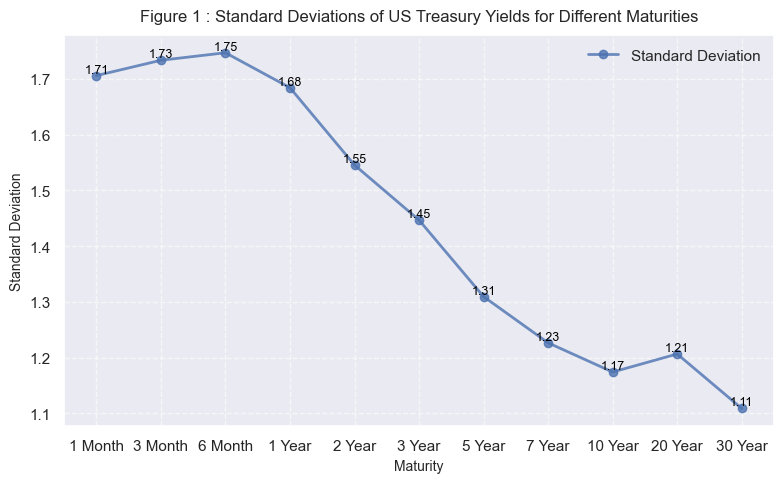

In [93]:

fig, ax = plt.subplots(figsize=(8, 5))

# Plot
ax.plot(
    y_std.index, 
    y_std.values, 
    marker='o', 
    alpha=0.8,
    linewidth=2,
    label="Standard Deviation"
)

# Labels and title
ax.set_title("Figure 1 : Standard Deviations of US Treasury Yields for Different Maturities", fontsize=12, pad=10)
ax.set_xlabel("Maturity", fontsize=10)
ax.set_ylabel("Standard Deviation", fontsize=10)

# Annotate each point
for x, y in zip(y_std.index, y_std.values):
    ax.text(
        x, y, f"{y:.2f}",
        ha='center', va='bottom',
        fontsize=9,
        color='black'
    )

# Styling
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### yield curve

Figure 3


C:\Users\Administrator\AppData\Local\Temp\ipykernel_22684\1329709245.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


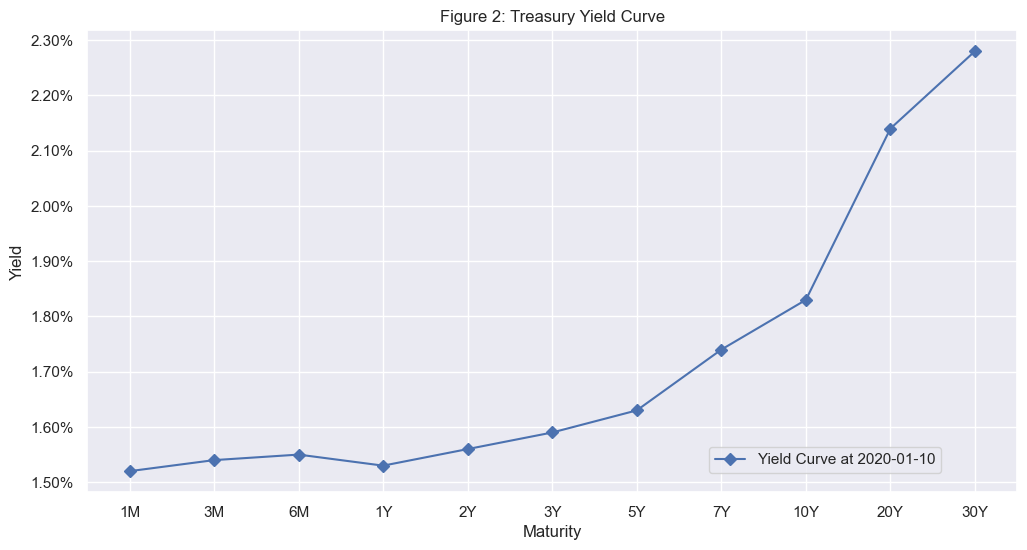

In [94]:
def plot_yield_curve(date, fig_n):
    maturities = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y'] # Maturities
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(maturities, yields.loc[date], marker='D', label='Yield Curve at ' + date)

    ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])
    ax.set_xticks(range(len(maturities)))
    ax.set_xticklabels(maturities)

    # Add labels and title
    ax.set_xlabel('Maturity')
    ax.set_ylabel('Yield')
    ax.set_title(fig_n+'Treasury Yield Curve')


    fig.legend(loc = [0.69, 0.14])

    # Show the plot
    plt.grid(True)
    plt.show()

print("Figure 3")
plot_yield_curve('2020-01-10','Figure 2: ')

### Fit a Nelson-Siegel model.  

y
(
t
)=
β
0
+
β
1
(
1
−
e
−
λ
t
λ
t
)
+
β
2
(
1
−
e
−
λ
t
λ
t
−
e
−
λ
t
)
+
ϵ

β
0
,
β
1
,
β
2
 are the parameters to be estimated. 
t
 is the time to maturity and 
λ
 is the decay rate. 

 

𝛽0: Long-term yield (level).

𝛽1: Short-term slope (difference between short- and long-term yields).

𝛽2: Medium-term curvature (hump shape).

λ: Decay rate, determines where the “hump” appears.

In [ ]:
!pip install nelson_siegel_svensson


In [21]:
from nelson_siegel_svensson.calibrate import calibrate_ns_ols
import numpy as np

In [73]:
# Create maturity and yield variables in array form
t = np.array([0.08333,0.25,0.5,1,2,3,5,7,10,20,30]) # maturities in years
y = np.array(yields.loc["2006-03-23"])
curve, status = calibrate_ns_ols(t, y, tau0=0.5)  # starting value of 0.5 for the optimization of tau
assert status.success
print(curve)

NelsonSiegelCurve(beta0=4.769301553939568, beta1=-0.18608573203545753, beta2=0.25937113055964856, tau=0.25704878221353844)


In [74]:
print("Nelson–Siegel parameters:")
print(f"β₀ (Level): {curve.beta0:.4f}")
print(f"β₁ (Slope): {curve.beta1:.4f}")
print(f"β₂ (Curvature): {curve.beta2:.4f}")
print(f"λ  (Decay rate): {curve.tau:.4f}")

Nelson–Siegel parameters:
β₀ (Level): 4.7693
β₁ (Slope): -0.1861
β₂ (Curvature): 0.2594
λ  (Decay rate): 0.2570


The positive β₂ and moderate λ indicate a modest hump in medium maturities (e.g., 5–10 years), while β₁ < 0 shows an upward sloping curve.

Text(0.5, 1.0, 'Figure 3:  Nelson-Siegel Model Result')

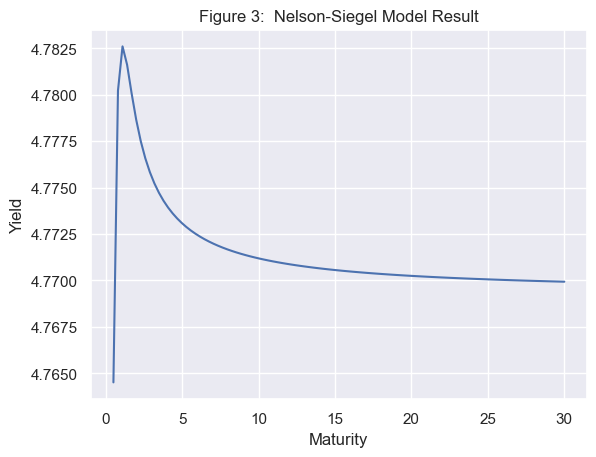

In [95]:
y_hat = curve
t_hat = np.linspace(0.5,30,100)
plt.plot(t_hat, y_hat(t_hat))
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("Figure 3:  Nelson-Siegel Model Result")

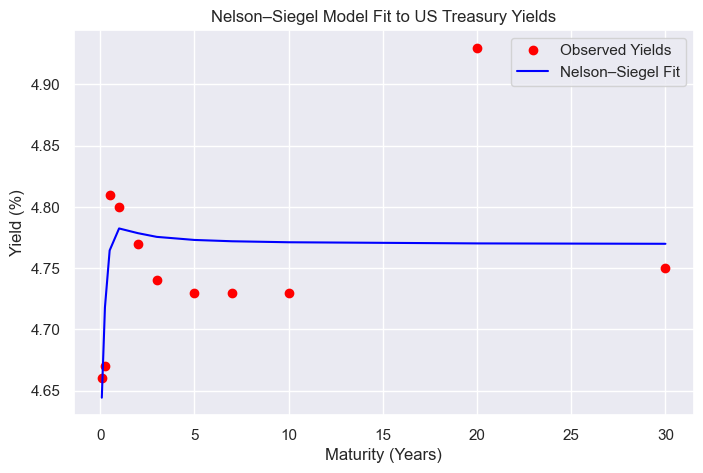

In [77]:
import matplotlib.pyplot as plt

y_fit = curve(t)  # fitted values

plt.figure(figsize=(8,5))
plt.plot(t, y, 'o', label='Observed Yields', color='red')
plt.plot(t, y_fit, '-', label='Nelson–Siegel Fit', color='blue')
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Nelson–Siegel Model Fit to US Treasury Yields")
plt.legend()
plt.grid(True)
plt.show()

### Fit a Cubic-Spline model. 

In [97]:
from scipy.interpolate import CubicSpline


In [98]:
yields.loc["2006-03-23"]

1 Month    4.66
3 Month    4.67
6 Month    4.81
1 Year     4.80
2 Year     4.77
3 Year     4.74
5 Year     4.73
7 Year     4.73
10 Year    4.73
20 Year    4.93
30 Year    4.75
Name: 2006-03-23 00:00:00, dtype: float64

In [99]:
t = np.array([0.08333,0.25,0.5,1,2,3,5,7,10,20,30])
y = np.array(yields.loc["2006-03-23"]) # yields on those maturities

In [100]:
cs = CubicSpline(t, y)
xs = np.linspace(2,30,100)
ys = cs(xs)

### Cubic spline coffecient values

In [101]:
print("Cubic Spline Coefficients (α values for each interval):")
for i in range(len(cs.c.T)):
    print(f"Interval {i+1}: {t[i]}–{t[i+1]} years")
    print(f"  α₀ = {cs.c[3, i]:.6f}")
    print(f"  α₁ = {cs.c[2, i]:.6f}")
    print(f"  α₂ = {cs.c[1, i]:.6f}")
    print(f"  α₃ = {cs.c[0, i]:.6f}")
    print("-" * 40)

Cubic Spline Coefficients (α values for each interval):
Interval 1: 0.08333–0.25 years
  α₀ = 4.660000
  α₁ = -0.421749
  α₂ = 3.566611
  α₃ = -4.057012
----------------------------------------
Interval 2: 0.25–0.5 years
  α₀ = 4.670000
  α₁ = 0.429047
  α₂ = 1.538064
  α₃ = -4.057012
----------------------------------------
Interval 3: 0.5–1.0 years
  α₀ = 4.810000
  α₁ = 0.437389
  α₂ = -1.504695
  α₃ = 1.179832
----------------------------------------
Interval 4: 1.0–2.0 years
  α₀ = 4.800000
  α₁ = -0.182431
  α₂ = 0.265053
  α₃ = -0.112622
----------------------------------------
Interval 5: 2.0–3.0 years
  α₀ = 4.770000
  α₁ = 0.009810
  α₂ = -0.072812
  α₃ = 0.033003
----------------------------------------
Interval 6: 3.0–5.0 years
  α₀ = 4.740000
  α₁ = -0.036807
  α₂ = 0.026195
  α₃ = -0.005146
----------------------------------------
Interval 7: 5.0–7.0 years
  α₀ = 4.730000
  α₁ = 0.006223
  α₂ = -0.004680
  α₃ = 0.000784
----------------------------------------
Interval 8:

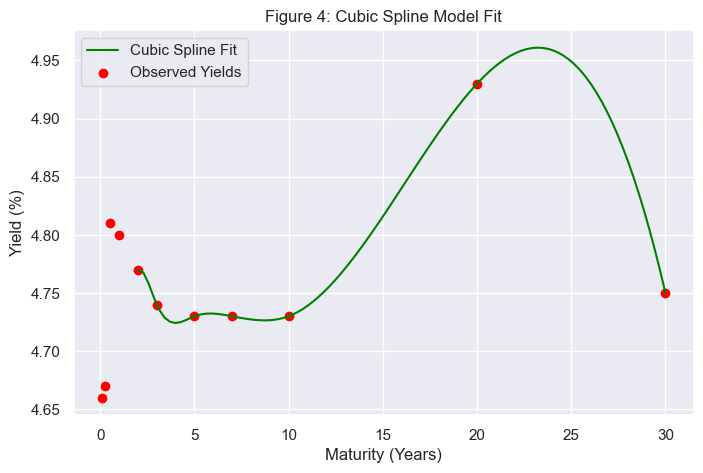

In [102]:

plt.figure(figsize=(8,5))
plt.plot(xs, ys, label='Cubic Spline Fit', color='green')
plt.scatter(t, y, color='red', label='Observed Yields')
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Figure 4: Cubic Spline Model Fit")
plt.legend()
plt.grid(True)
plt.show()

### Compare both models

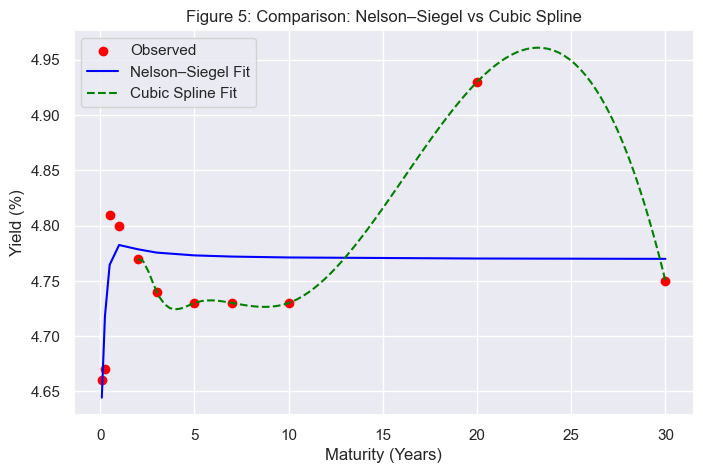

In [104]:
plt.figure(figsize=(8,5))
plt.scatter(t, y, color='red', label='Observed')
plt.plot(t, curve(t), label='Nelson–Siegel Fit', color='blue')
plt.plot(xs, cs(xs), label='Cubic Spline Fit', color='green', linestyle='--')
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Figure 5: Comparison: Nelson–Siegel vs Cubic Spline")
plt.legend()
plt.grid(True)
plt.show()

### Comparison of Nelson–Siegel vs Cubic Spline Models

| Aspect | **Nelson–Siegel Model** | **Cubic Spline Model** |
|:-------|:--------------------------|:--------------------------|
| **1. Fit** | Provides a smooth, parsimonious fit using only a few parameters (β₀, β₁, β₂, λ). It captures the overall shape of the yield curve — level, slope, and curvature — but may not fit local irregularities perfectly. | Offers a very close fit to the observed data points, especially between maturities. However, it can **overfit** or oscillate between points (as seen around 20–25 years), producing unrealistic shapes beyond observed maturities. |
| **2. Interpretation** | Parameters have **clear economic meaning**: β₀ represents the long-term level, β₁ the short-term slope, β₂ the curvature, and λ the decay rate controlling how quickly yields converge. This makes it suitable for **economic analysis and forecasting**. | The spline coefficients have **no direct economic interpretation**. It is a purely mathematical interpolation method used for smoothing and curve fitting, not for interpreting macroeconomic factors. |

**Summary:**  
The **Nelson–Siegel model** is more interpretable and stable for understanding yield curve dynamics, while the **Cubic Spline model** provides a more flexible and accurate fit to the data but lacks theoretical meaning.  
For analytical and policy applications, **Nelson–Siegel** is preferred; for purely numerical interpolation or visualization, **Cubic Spline** performs better.


If Nelson-Siegel is smoothing the yield curve, is this considered unethical? Why or why not?  


### Ethical Considerations of Nelson–Siegel Smoothing

- The **Nelson–Siegel model** smooths the yield curve mathematically to capture its fundamental structure — **level, slope, and curvature**.  
- This process helps analysts and policymakers **extract meaningful trends** from noisy market data.  
- **Smoothing itself is not unethical** — it is a standard statistical technique used to summarize and interpret data.  
- The model’s parameters (β₀, β₁, β₂, λ) are **transparent and interpretable**, allowing users to understand how the curve behaves.  
- The goal is **insight and simplification**, not manipulation — it helps forecast rates and manage interest rate risk.  
- It becomes **unethical only if used deceptively**, such as:
  - Hiding short-term yield fluctuations to present a false sense of market stability.  
  - Misrepresenting model outputs as actual observed data.  
  - Cherry-picking parameters to produce desired policy outcomes.  
- **Ethical use** requires transparency about:
  - The data sources (e.g., Treasury yields from FRED).  
  - The model assumptions and estimation process.  
  - The limitations and potential errors of the model.  
- Regulators and central banks (e.g., the Fed, ECB) use Nelson–Siegel models ethically as part of **official yield curve estimation frameworks**.  
- In summary, **smoothing with Nelson–Siegel is ethical** when used for analysis, communication, or policy research — **not to distort or conceal** the underlying reality.
